### <b>Análisis y predicción de datos: Football Salaries FIFA 22</b>
#### <b><i>Introducción</i></b>
El mundo del fútbol, antiguamente, no se regía mucho por el dinero: era más pasión, juego, calidad y talento. Brasil dominaba en los años 90 con el jogo bonito. Equipazos como la alemania de los 70, la naranaja mecánica del fútbol total de Cruyff. La argentina del 86 de Maradona, entre otros clubes y selecciones históricas. Los fichajes y sueldos realmente no eran del todo llamativos, aunque relevancia sí tenían. Antes de la <b>Ley Bosman</b>, los jugadores extranjeros solo eran permitidos en los clubes europeos con una <b>cantidad máxima de 3</b>. Empero, a la postre de la imposición de dicha ley, todo cambió. Fichajes exorbitantes, sueldos inimaginables y dinero por todos lados. Por mencionar un ejemplo: el fichaje de Luis Figo por el Real Madrid. O más recientemente, Paul Pogba por el United, Neymar por el PSG, entre otros. Esto ha llevado a los clubes a pagar cifras exorbitantes no solo por el fichaje, sino por el jugador en sí, para mantenerlo. Esto se debe a múltiples factores, pero estos factores y todo el análisis nace de la siguiente pregunta: <b>¿Por qué sueldos tan altos?</b>
    
En nuestro afán de responder dicha pregunta, se realiza el siguiente estudio, donde se buscará predecir cuáles son esos factores que influyen en la asignación de una masa salarial alta o baja en los jugadores: ¿De qué depende? ¿Es la expectativa? ¿Es la trayectoria? ¿Es la edad? 
Todo ello lo abordaremos durante el desarrollo del estudio. 

### <b>¿Qué usaremos?</b>
Para el desarollo del estudio, utilizaremos el archivo <b><i>dataset.csv</i></b>, en el cual se encontrará un registro de todos los datos de +19 mil jugadores, y atributos que se consideraron relevantes para anotar. A continuación se muestra el diccionario de variables:

#### <b>Diccionario de datos</b>
| Variable | Tipo | Descripción | Comentario |
|----------|------|-------------|------------|
| `age` | Numérica | Edad del jugador profesional en años; útil para analizar la madurez deportiva y la etapa de la carrera. | Sports analytics |
| `height_cm` | Numérica | Estatura del jugador en centímetros. | Sports analytics |
| `weight_kg` | Numérica | Peso del jugador en kilogramos. | Sports analytics |
| `nationality_name` | Categórica | Nacionalidad del jugador. | Sports analytics |
| `overall` | Numérica | Valoración general (Overall) del jugador. | Sports analytics |
| `potential` | Numérica | Potencial máximo estimado del jugador. | Sports analytics |
| `attacking_crossing` | Numérica | Habilidad para realizar centros. | Sports analytics |
| `attacking_finishing` | Numérica | Capacidad de definición frente al arco. | Sports analytics |
| `attacking_heading_accuracy` | Numérica | Precisión en los remates de cabeza. | Sports analytics |
| `attacking_short_passing` | Numérica | Precisión en los pases cortos. | Sports analytics |
| `attacking_volleys` | Numérica | Habilidad para ejecutar voleas. | Sports analytics |
| `skill_dribbling` | Numérica | Nivel de regate del jugador. | Sports analytics |
| `skill_curve` | Numérica | Capacidad para dar efecto al balón. | Sports analytics |
| `skill_fk_accuracy` | Numérica | Precisión en tiros libres. | Sports analytics |
| `skill_long_passing` | Numérica | Precisión en pases largos. | Sports analytics |
| `skill_ball_control` | Numérica | Control del balón. | Sports analytics |
| `movement_acceleration` | Numérica | Capacidad de aceleración. | Sports analytics |
| `movement_sprint_speed` | Numérica | Velocidad máxima de sprint. | Sports analytics |
| `movement_agility` | Numérica | Agilidad del jugador. | Sports analytics |
| `movement_reactions` | Numérica | Rapidez de reacción ante las jugadas. | Sports analytics |
| `movement_balance` | Numérica | Equilibrio corporal. | Sports analytics |
| `defending_standing_tackle` | Numérica | Eficacia en entradas de pie. | Sports analytics |
| `defending_sliding_tackle` | Numérica | Eficacia en entradas deslizantes. | Sports analytics |
| `goalkeeping_diving` | Numérica | Capacidad del portero para lanzarse. | Sports analytics |
| `goalkeeping_handling` | Numérica | Seguridad al atrapar el balón. | Sports analytics |
| `goalkeeping_kicking` | Numérica | Precisión y potencia en los despejes del portero. | Sports analytics |
| `goalkeeping_positioning` | Numérica | Posicionamiento del portero. | Sports analytics |
| `goalkeeping_reflexes` | Numérica | Reflejos del portero. | Sports analytics |
| `wage_eur` | Numérica | **Variable objetivo (Target): salario del jugador expresado en euros.** | Objetivo del modelo |

### <b><i>Fase I:</i> Análisis Exploratorio de Datos (EDA)</b>
En esta etapa tendremos 4 objetivos claros y específicos:
1. Determinar la calidad de los datos: identificar missing values, valores incoherentes, repetición de data (duplicados).
2. Descubriremos cuál es la distribución de la variable objetivo.
3. Analizaremos las variables que se consideren más relevantes para el estudio.
4. Expondremos nuestros hallazgos de manera que sea entendible en el contexto futbolístico.

#### <b><i>1. Determinación de la calidad de los datos</i></b>
Esta parte es fundamental en un EDA, ya que nos permite saber si los datos son óptimos para el correcto análisis y procesamiento. Dentro del desarrollo de esta parte, corresponde identificar lo siguiente:
- Valores missing
- Valores duplicados
- Valores incoherentes

In [1]:
"""
======== DETERMINACIÓN DE LA CALIDAD DE DATOS DEL MODELO =========
"""

# Importamos las librerías necesarias
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sbs

In [2]:
# Obtenemos la ruta e importamos el dataframe
path = os.path.join(os.getcwd(), "..", "data", "raw", "dataset.csv")
df = pd.read_csv(path)
df.head(10)

,age,height_cm,weight_kg,nationality_name,overall,potential,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,...,movement_reactions,movement_balance,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,wage_eur
0,34,170,72,Argentina,93,93,85,95,70,91,...,94,95,35,24,6,11,15,14,8,320000.0
1,32,185,81,Poland,92,92,71,95,90,85,...,93,82,42,19,15,6,12,8,10,270000.0
2,36,187,83,Portugal,91,91,87,95,90,80,...,94,74,32,24,7,11,15,14,11,270000.0
3,29,175,68,Brazil,91,91,85,83,63,86,...,89,84,32,29,9,9,15,15,11,270000.0
4,30,181,70,Belgium,91,91,94,82,55,94,...,91,78,65,53,15,13,5,10,13,350000.0
5,28,188,87,Slovenia,91,93,13,11,15,43,...,88,49,12,18,87,92,78,90,90,130000.0
6,22,182,73,France,91,95,78,93,72,85,...,93,83,34,32,13,5,7,11,6,230000.0
7,35,193,93,Germany,90,90,15,13,25,60,...,87,35,10,11,88,88,91,89,88,86000.0
8,29,187,85,Germany,90,92,18,14,11,61,...,86,43,13,10,88,85,88,88,90,250000.0
9,27,188,89,England,90,90,80,94,86,85,...,92,70,36,38,8,10,11,14,11,240000.0


### <b>1. Calidad de los datos y limpieza</b>
##### <b>A. Valores missing</b>

In [3]:
# A. Limpieza de datos
# Valores missing
missing = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Porcentaje": (df.isnull().sum()/len(df))*100
})

missing

,Missing,Porcentaje
age,0,0.0
height_cm,0,0.0
weight_kg,0,0.0
nationality_name,0,0.0
overall,0,0.0
potential,0,0.0
attacking_crossing,0,0.0
attacking_finishing,0,0.0
attacking_heading_accuracy,0,0.0
attacking_short_passing,0,0.0


#### <b><i>Conclusión</i></b>
Según el dataset proporcionado y la manipulación de código llevada a cabo, se llega a la conclusión de que el dataset no posee ningún dato faltante y que cada celda está completa. Esto es un buen inidicio de que el csv. fue entregado con completitud de datos y no hará falta ajustes adicionales.

#### <b><i>Decisión</i></b>
No se modificará el dataset.

##### <b>B. Valores duplicados</b>

In [4]:
# Valores duplicados
# Cantidad de duplicados
duplicados = df.duplicated().sum()
print(f"La cantidad de duplicados es: {duplicados}")

# Comprobamos viendo los duplicados
df[df.duplicated()]

La cantidad de duplicados es: 0


,age,height_cm,weight_kg,nationality_name,overall,potential,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,...,movement_reactions,movement_balance,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,wage_eur


#### <b><i>Conclusión</i></b>
Según el dataset proporcionado y la manipulación de código llevada a cabo, se llega a la conclusión de que el dataset no posee ninguna fila duplicada en todoo su contenido.

#### <b><i>Decisión</i></b>
No se modificará el dataset.

##### <b>C. Valores incoherentes</b>

In [5]:
# C. Valores incoherentes
# C.1. Valores negativos
numeric_columns = [
    "age",
    "height_cm",
    "weight_kg",
    "overall",
    "potential",
    "attacking_crossing",
    "attacking_finishing",
    "attacking_heading_accuracy",
    "attacking_short_passing",
    "attacking_volleys",
    "skill_dribbling",
    "skill_curve",
    "skill_fk_accuracy",
    "skill_long_passing",
    "skill_ball_control",
    "movement_acceleration",
    "movement_sprint_speed",
    "movement_agility",
    "movement_reactions",
    "movement_balance",
    "defending_standing_tackle",
    "defending_sliding_tackle",
    "goalkeeping_diving",
    "goalkeeping_handling",
    "goalkeeping_kicking",
    "goalkeeping_positioning",
    "goalkeeping_reflexes",
    "wage_eur"
]
negatives = df[df[numeric_columns] < 0]

#Buscamos elementos NO nulos
negatives = pd.DataFrame({
    "Negativos": negatives.count()
})
negatives

,Negativos
age,0
height_cm,0
weight_kg,0
nationality_name,0
overall,0
potential,0
attacking_crossing,0
attacking_finishing,0
attacking_heading_accuracy,0
attacking_short_passing,0


#### <b><i>Conclusión</i></b>
Según el dataset proporcionado y la manipulación de código llevada a cabo, se llega a la conclusión de que el dataset no posee ningún elemento negativo que sea completamente incoherente con lo medido.

#### <b><i>Decisión</i></b>
No se modificará el dataset.

In [6]:
# C.2. Cardinalidad y unicidad de variable categórica
all_countries = df["nationality_name"].value_counts()
unique_countries = all_countries[all_countries == 1]
print("Nacionalidades que aparecen una vez: ", len(unique_countries))
unique_countries

Nacionalidades que aparecen una vez:  20


nationality_name
Tanzania            1
Fiji                1
Bermuda             1
Eritrea             1
Mauritius           1
Guam                1
Kyrgyzstan          1
Papua New Guinea    1
Ethiopia            1
Andorra             1
Korea DPR           1
Saint Lucia         1
Afghanistan         1
Vietnam             1
Belize              1
Bhutan              1
Barbados            1
Gibraltar           1
Estonia             1
Indonesia           1
Name: count, dtype: int64

In [7]:
not_unique_countries = all_countries[all_countries > 1]
print("Nacionalidades que aparecen más una vez: ", len(not_unique_countries))
not_unique_countries

Nacionalidades que aparecen más una vez:  143


nationality_name
England      1719
Germany      1214
Spain        1086
France        980
Argentina     960
             ... 
Lebanon         2
Guatemala       2
Palestine       2
Malaysia        2
Hong Kong       2
Name: count, Length: 143, dtype: int64

#### <b><i>Conclusión</i></b>
Según el dataset proporcionado y la manipulación de código llevada a cabo, se llega a la conclusión de que el dataset no posee ningún elemento incoherente con respecto a la variable categórica "nationality_name". Esto debido a que no se presentan países escritos con intercalo de letras mayúsculas y minúsculas. Es decir, no aparecen como datos únicos "Argentina" y "ARGENTINA", por ejemplo.
Asimismo, podemos observar la cardinalidad de todos los países (cuántas veces aparece cada nacionalidad). Esta cardinalidad nos permite decidir a qué países ponerle foco principalmente y hacer el estudio únicamente con ellos.

#### <b><i>Decisión</i></b>
Para facilitar nuestro estudios y reducir el número de la muestra por visibilidad gráfica, nos quedaremos con el top 20 países con más jugadores. La decisión viene respaldada del siguiente script, donde se encuentra como resultado que el 63.8% de todos los jugadores se encuentra en el top 20 de países con más jugadores.

In [8]:
# Obtenemos el top 20
top_twenty_countries = all_countries[:20]
percentage = (top_twenty_countries.sum()/all_countries.sum())*100
print(f"El porcentaje de jugadores que se encuentra en el top 20 es: {percentage}%")
top_twenty_countries

El porcentaje de jugadores que se encuentra en el top 20 es: 63.896130983418495%


nationality_name
England                1719
Germany                1214
Spain                  1086
France                  980
Argentina               960
Brazil                  897
Japan                   546
Netherlands             439
United States           413
Poland                  401
China PR                385
Sweden                  384
Norway                  379
Portugal                373
Republic of Ireland     373
Saudi Arabia            355
Mexico                  352
Italy                   338
Romania                 335
Korea Republic          325
Name: count, dtype: int64

In [9]:
# C.3. Variables outliers (solo para numéricas)
"""
    Acotación: utilizaremos dos arrays, uno que será de atributos de jugadores de campo;
    otro, para arqueros y otro de atributo generales. Esto debido a que podemos detectar 
    como outliers atributos de jugadores de campo para arqueros, y esto no nos daría un 
    análisis concreto y bien hecho.
"""
# C.3.1. Jugadores: Creamos la lista
numeric_columns_footballer = [
    "attacking_crossing",
    "attacking_finishing",
    "attacking_heading_accuracy",
    "attacking_short_passing",
    "attacking_volleys",
    "skill_dribbling",
    "skill_curve",
    "skill_fk_accuracy",
    "skill_long_passing",
    "skill_ball_control",
    "movement_acceleration",
    "movement_sprint_speed",
    "movement_agility",
    "movement_reactions",
    "movement_balance",
    "defending_standing_tackle",
    "defending_sliding_tackle",
]
# Utilizamos cuantiles 1 y 3
q1 = df[numeric_columns_footballer].quantile(0.25)
q3 = df[numeric_columns_footballer].quantile(0.75)

# Distancia Intercuartil
iqr = q3 - q1

# Límites
limite_inf = q1 - 1.5*iqr
limite_sup = q3 + 1.5*iqr

# Filtro
outliers_footballer = df[((df[numeric_columns_footballer] < limite_inf) | (df[numeric_columns_footballer] > limite_sup)).any(axis=1)]
print(outliers_footballer.shape)
outliers_footballer.head()

(2655, 29)


,age,height_cm,weight_kg,nationality_name,overall,potential,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,...,movement_reactions,movement_balance,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,wage_eur
0,34,170,72,Argentina,93,93,85,95,70,91,...,94,95,35,24,6,11,15,14,8,320000.0
1,32,185,81,Poland,92,92,71,95,90,85,...,93,82,42,19,15,6,12,8,10,270000.0
2,36,187,83,Portugal,91,91,87,95,90,80,...,94,74,32,24,7,11,15,14,11,270000.0
3,29,175,68,Brazil,91,91,85,83,63,86,...,89,84,32,29,9,9,15,15,11,270000.0
4,30,181,70,Belgium,91,91,94,82,55,94,...,91,78,65,53,15,13,5,10,13,350000.0


<b>Explicación</b>: Lo que hemos obtenido aquí es a <b>TODOS LOS JUGADORES QUE TENGAN POR LO MENOS UN ATRIBUTO OUTLIER SEGÚN LOS ATRIBUTOS QUE CORRESPONDAN A JUGADOR DE CAMPO (NO PORTERO)</b>.

Tengamos en cuenta nuestro contexto: Para poder hacer un buen análisis, necesitamos saber los valores outliers si o si. Sin embargo, debemos saber qué valores outliers tenemos también, es decir, su valor exacto. Ya sabemos, por el análisis anterior en C.1. que no tenemos negativos. Está bien, pero por ejemplo, podríamos tener a jugadores con edad 1, o podríamos tener a jugadores con edad 60. Técnicamente, no es imposible, pero claramente la probabilidad es ridículamente baja. Entonces, ese tipo de valores, son outliers sin sentido, que se deben remover. De igual forma, si se encontrara a un jugador con más de la mitad de atributos como outlier, se pensaría directamente que no es de este planeta, y sería muy raro, entonces, ese tipo de datos, también se borran. 

Sin embargo, existen excepcione, donde por ejemplo, un jugador podría tener 7, 8 outliers. Un ejemplo, Lionel Messi, con un `wage_eur` demasiado alto, entre otras habilidades. U otros jugadores como Kylian Mbappé, o Lamine Yamal. Tenemos que tener cuidado ya que son ESOS CASOS los que nos gustaría analizar y son los que deseamos predecir y entender QUÉ FACTORES realmente influyen en que esos jugadores tengan un salario tan alto.

In [10]:
#Ahora, identifiquemos la cantidad de outliers por cada jugador que tenga al menos 1 outlier
condicion_outliers = df[numeric_columns_footballer].lt(limite_inf, axis=1) | df[numeric_columns_footballer].gt(limite_sup, axis=1)
df["cantidad_outliers"] = condicion_outliers.sum(axis=1)
outliers_footballer = df[condicion_outliers.any(axis=1)]
print("La cantidad total de filas con al menos 1 outlier es:", len(outliers_footballer))
print("Porcentaje representativo: ", (len(outliers_footballer)/len(df))*100, "%")
outliers_footballer

La cantidad total de filas con al menos 1 outlier es: 2655
Porcentaje representativo:  13.843987902805296 %


,age,height_cm,weight_kg,nationality_name,overall,potential,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,...,movement_balance,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,wage_eur,cantidad_outliers
0,34,170,72,Argentina,93,93,85,95,70,91,...,95,35,24,6,11,15,14,8,320000.0,5
1,32,185,81,Poland,92,92,71,95,90,85,...,82,42,19,15,6,12,8,10,270000.0,1
2,36,187,83,Portugal,91,91,87,95,90,80,...,74,32,24,7,11,15,14,11,270000.0,1
3,29,175,68,Brazil,91,91,85,83,63,86,...,84,32,29,9,9,15,15,11,270000.0,2
4,30,181,70,Belgium,91,91,94,82,55,94,...,78,65,53,15,13,5,10,13,350000.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19164,21,175,77,India,47,55,11,7,10,26,...,41,12,12,48,45,45,46,47,500.0,5
19166,18,186,74,India,47,67,13,8,10,22,...,44,14,13,49,41,39,45,49,500.0,7
19167,19,161,63,India,47,67,29,50,34,43,...,71,16,11,8,6,14,11,14,500.0,1
19170,22,181,74,India,47,55,13,8,13,20,...,43,13,13,49,46,43,47,52,500.0,7


Hemos encontrado que <b>2655 jugadores tienen al menos un outlier.</b> Esto representa un <b>13.84% de los 19178 jugadores incluidos en el dataset.</b> No es un procentaje alto, de hecho, representa una pequeña parte del total de los jugadores. Sin embargo, son los casos que más relevancia tienen en nuestro estudio. Este tipo de casos nos permitirán entender por qué Messi es el jugador mejor pagado del planeta, o por qué otros supercracks mundiales ganan tanto.

Entonces, no me interesará mucho saber la cantidad de jugadores que cuentan con estos valores outliers, sino cuál es el porcentaje de outliers en cada columna para poder considerar los atributos más importantes.

In [11]:
# Calculemos el porcentaje de outliers por columna
percentages = (condicion_outliers.sum()/len(df))*100
percentages

attacking_crossing             0.000000
attacking_finishing            0.000000
attacking_heading_accuracy     6.199812
attacking_short_passing        9.344040
attacking_volleys              0.000000
skill_dribbling               11.007404
skill_curve                    0.000000
skill_fk_accuracy              0.015643
skill_long_passing             0.297216
skill_ball_control            11.507978
movement_acceleration          3.373657
movement_sprint_speed          4.692877
movement_agility               1.334863
movement_reactions             1.861508
movement_balance               1.559078
defending_standing_tackle      0.000000
defending_sliding_tackle       0.000000
dtype: float64

In [12]:
# Obtenemos los 3 porcentajes más altos
ordered_percentages = percentages.sort_values() # sort_values ordena de menor a mayor
ordered_percentages[-3:]

attacking_short_passing     9.344040
skill_dribbling            11.007404
skill_ball_control         11.507978
dtype: float64

Hemos obtenido todos los porcentajes, y también hemos determinado cuáles son los 3 más altos. Es así, que podemos decir que los atributos `attacking_short_passing`, `skill_dribbling` y `skill_ball_control` son aquellos que tienen el mayor número de outliers. Por lo tanto, serán elementos diferenciadores en el análisis y la predicción del sueldos de los futbolistas.

Con respecto a la limpieza de datos, dado que en loss otros atributos no se han identificado porcentajes lo suficientemente significativos ni valores completamente extraño, solo un poco fuera del rango intercuartil, entonces, no se limpiará ninguna fila outlier.

#### <b><i>Decisión</i></b>
Dado el análisis realizado y la obtención de los valores outliers, no se determinaron valores lo suficientemente alejados de la realidad como para tomar la decisión de eliminar alguna fila. Por lo tanto, no se borrará dado este motivo. Además, la evidencia hallada resulta fundamental para la futura predicción de sueldos.

In [13]:
# C.3.2. Portero: Creamos la lista
numeric_columns_gk = [
    "goalkeeping_diving",
    "goalkeeping_handling",
    "goalkeeping_kicking",
    "goalkeeping_positioning",
    "goalkeeping_reflexes",
]

# Utilizamos cuantiles 1 y 3
q1 = df[numeric_columns_gk].quantile(0.25)
q3 = df[numeric_columns_gk].quantile(0.75)

# Distancia Intercuartil
iqr = q3 - q1

# Límites
limite_inf_gk = q1 - 1.5*iqr
limite_sup_gk = q3 + 1.5*iqr

# Filtro
outliers_gk = df[((df[numeric_columns_gk] < limite_inf_gk) | (df[numeric_columns_gk] > limite_sup_gk)).any(axis=1)]
print(outliers_gk.shape)
outliers_gk.head().drop(columns=["cantidad_outliers"])

(2132, 30)


,age,height_cm,weight_kg,nationality_name,overall,potential,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,...,movement_reactions,movement_balance,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,wage_eur
5,28,188,87,Slovenia,91,93,13,11,15,43,...,88,49,12,18,87,92,78,90,90,130000.0
7,35,193,93,Germany,90,90,15,13,25,60,...,87,35,10,11,88,88,91,89,88,86000.0
8,29,187,85,Germany,90,92,18,14,11,61,...,86,43,13,10,88,85,88,88,90,250000.0
12,29,199,96,Belgium,89,91,14,14,13,33,...,84,45,18,16,84,89,74,86,88,250000.0
18,27,188,86,Brazil,89,91,20,14,14,61,...,88,48,15,8,87,82,93,88,88,200000.0


Al igual que con los jugadores, para los porteros se hace un análisis separado dado que las habilidades de estos difieren de las de los jugadores de campo. Es decir, las habilidades del portero están siendo aisladas para un estudio más compacto y preciso. Procederemos a hacer un análisis similar de igual forma.

In [14]:
#Ahora, identifiquemos la cantidad de outliers por cada jugador que tenga al menos 1 outlier de los atributos de portero
condicion_outliers_gk = df[numeric_columns_gk].lt(limite_inf_gk, axis=1) | df[numeric_columns_gk].gt(limite_sup_gk, axis=1)
df["cantidad_outliers_gk"] = condicion_outliers_gk.sum(axis=1)
outliers_gk = df[condicion_outliers_gk.any(axis=1)]
print("La cantidad total de filas con al menos 1 outlier es:", len(outliers_gk))
print("Porcentaje representativo: ", (len(outliers_gk)/len(df))*100, "%")
outliers_gk.drop(columns=["cantidad_outliers"])

La cantidad total de filas con al menos 1 outlier es: 2132
Porcentaje representativo:  11.1169047867348 %


,age,height_cm,weight_kg,nationality_name,overall,potential,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,...,movement_balance,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,wage_eur,cantidad_outliers_gk
5,28,188,87,Slovenia,91,93,13,11,15,43,...,49,12,18,87,92,78,90,90,130000.0,5
7,35,193,93,Germany,90,90,15,13,25,60,...,35,10,11,88,88,91,89,88,86000.0,5
8,29,187,85,Germany,90,92,18,14,11,61,...,43,13,10,88,85,88,88,90,250000.0,5
12,29,199,96,Belgium,89,91,14,14,13,33,...,45,18,16,84,89,74,86,88,250000.0,5
18,27,188,86,Brazil,89,91,20,14,14,61,...,48,15,8,87,82,93,88,88,200000.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19149,20,182,70,China PR,48,54,13,8,12,14,...,43,15,16,46,49,51,48,51,800.0,5
19155,19,180,72,England,48,65,12,5,12,29,...,48,12,13,52,49,49,43,48,1000.0,5
19164,21,175,77,India,47,55,11,7,10,26,...,41,12,12,48,45,45,46,47,500.0,5
19166,18,186,74,India,47,67,13,8,10,22,...,44,14,13,49,41,39,45,49,500.0,5


Al igual que en el ejercicio anterior, lo que nos interesa es conocer el porcentaje de outliers por cada atributo correspondiente a los arqueros, por lo tanto, en el siguiente script, calcularemos dichos porcentajes.

In [15]:
percentages_gk = (condicion_outliers_gk.sum()/len(df))*100
percentages_gk

goalkeeping_diving         11.090833
goalkeeping_handling       11.090833
goalkeeping_kicking        11.111690
goalkeeping_positioning    11.090833
goalkeeping_reflexes       11.096048
dtype: float64

Podemos observar que practicamente todos los atributos correspondientes a los arqueros tienen un porcentaje de outliers similar. Entonces, resulta relevante analizar cada variable correspondiente a los arqueros en nuestro estudio.

#### <b><i>Decisión</i></b>
Dado el análisis realizado y la obtención de los valores outliers, no se determinaron valores lo suficientemente alejados de la realidad como para tomar la decisión de eliminar alguna fila. Por lo tanto, no se borrará dado este motivo. Además, la evidencia hallada resulta fundamental para la futura predicción de sueldos.

In [16]:
# C.3.3. Valores comunes (age, height_cm, weight_kg, overall, potential y wage_eur)
common_values = [
    "age",
    "height_cm",
    "weight_kg",
    "overall",
    "potential",
    "wage_eur"
]

# Utilizamos los cuantiles q1 y q3
q1 = df[common_values].quantile(0.25)
q3 = df[common_values].quantile(0.75)

# Distancia Intercuartil
iqr = q3 - q1

# Límites
limite_inf_common = q1 - 1.5*iqr
limite_sup_common = q3 + 1.5*iqr

# Outliers
outlier_common = df[((df[common_values] < limite_inf_common) | (df[common_values] > limite_sup_common)).any(axis=1)]
print(outlier_common.shape)
outlier_common.drop(columns = ["cantidad_outliers", "cantidad_outliers_gk"])

(2570, 31)


,age,height_cm,weight_kg,nationality_name,overall,potential,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,...,movement_reactions,movement_balance,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,wage_eur
0,34,170,72,Argentina,93,93,85,95,70,91,...,94,95,35,24,6,11,15,14,8,320000.0
1,32,185,81,Poland,92,92,71,95,90,85,...,93,82,42,19,15,6,12,8,10,270000.0
2,36,187,83,Portugal,91,91,87,95,90,80,...,94,74,32,24,7,11,15,14,11,270000.0
3,29,175,68,Brazil,91,91,85,83,63,86,...,89,84,32,29,9,9,15,15,11,270000.0
4,30,181,70,Belgium,91,91,94,82,55,94,...,91,78,65,53,15,13,5,10,13,350000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19173,22,180,64,China PR,47,52,46,32,48,50,...,53,70,43,48,6,10,5,15,13,1000.0
19174,19,175,70,Republic of Ireland,47,59,54,33,46,51,...,49,69,44,47,11,12,6,8,10,500.0
19175,21,178,72,Republic of Ireland,47,55,39,32,43,49,...,46,59,44,48,8,6,7,10,6,500.0
19176,19,173,66,Republic of Ireland,47,60,29,49,40,38,...,48,73,14,11,7,10,7,14,15,500.0


En este último estudio estamos tomando los atributos comunes de todos (sea portero, sea jugador). El análisis, entonces, resulta ser de 3 bloques: atributos comunes, atributos de portero y atributos de jugador de campo. Procedemos de la misma manera que los anteriores casos.

In [17]:
#Ahora, identifiquemos la cantidad de outliers por cada jugador que tenga al menos 1 outlier de los atributos comunes
condicion_outliers_common = df[common_values].lt(limite_inf_common, axis=1) | df[common_values].gt(limite_sup_common, axis=1)
df["cantidad_outliers_common"] = condicion_outliers_common.sum(axis=1)
outliers_common = df[condicion_outliers_common.any(axis=1)]
print("La cantidad total de filas con al menos 1 outlier es:", len(outliers_common))
print("Porcentaje representativo: ", (len(outliers_common)/len(df))*100, "%")
outliers_common.drop(columns=["cantidad_outliers", "cantidad_outliers_gk"])

La cantidad total de filas con al menos 1 outlier es: 2570
Porcentaje representativo:  13.400771717593074 %


,age,height_cm,weight_kg,nationality_name,overall,potential,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,...,movement_balance,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,wage_eur,cantidad_outliers_common
0,34,170,72,Argentina,93,93,85,95,70,91,...,95,35,24,6,11,15,14,8,320000.0,3
1,32,185,81,Poland,92,92,71,95,90,85,...,82,42,19,15,6,12,8,10,270000.0,3
2,36,187,83,Portugal,91,91,87,95,90,80,...,74,32,24,7,11,15,14,11,270000.0,3
3,29,175,68,Brazil,91,91,85,83,63,86,...,84,32,29,9,9,15,15,11,270000.0,3
4,30,181,70,Belgium,91,91,94,82,55,94,...,78,65,53,15,13,5,10,13,350000.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19173,22,180,64,China PR,47,52,46,32,48,50,...,70,43,48,6,10,5,15,13,1000.0,2
19174,19,175,70,Republic of Ireland,47,59,54,33,46,51,...,69,44,47,11,12,6,8,10,500.0,1
19175,21,178,72,Republic of Ireland,47,55,39,32,43,49,...,59,44,48,8,6,7,10,6,500.0,1
19176,19,173,66,Republic of Ireland,47,60,29,49,40,38,...,73,14,11,7,10,7,14,15,500.0,1


In [18]:
percentages_common = (condicion_outliers_common.sum()/len(df))*100
percentages_common

age           0.031286
height_cm     0.140786
weight_kg     0.344144
overall       0.829075
potential     0.834289
wage_eur     12.488268
dtype: float64

Podemos observar, que en su mayoría, las variables comunes a todos están normales, no es nada del otro mundo. Lo que nos dice que este dataset lleno de jugadores, en promedio, se distribuyen todos de la misma manera. Sin embargo, la mayor diferencia la encontramos en la variable target `wage_eur`, con un 12.5% de outliers con respecto al total. Eso quiere decir que nuestro objetivo será explicar por qué existe ese porcentaje de outliers en nuestra variable target.

### <b> CONCLUSIÓN FINAL DEL BLOQUE </b>
Según el estudio realizado al dataset, los hallazgos nos dicen la mayoría de datos <b>son relevantes para nuestro estudio</b> debido a que no existen valores duplicados, missing ni outliers sin sentido. Es más, los outliers son la parte más interesante del estudio debido a que la mayor cantidad de estos podemos encontrarla en la variable `wage_eur` que es nuestra variable target y la que intentaremos predecir mediante regresión. Es así que se tomará como decisión <b>no eliminar ninguna fila del dataset y conservarlo tal cual fue entregado</b>.

En la siguiente parte de nuestro estudio exploraremos todos los datos que hemos tomado, analizaremos gráficos y tomaremos decisiones para poder seguir mejorando la calidad de nuestro estudio.

Antes de continuar, limpiemos las columnas creadas.

In [19]:
# Verificamos las columnas
df.columns

Index(['age', 'height_cm', 'weight_kg', 'nationality_name', 'overall',
       'potential', 'attacking_crossing', 'attacking_finishing',
       'attacking_heading_accuracy', 'attacking_short_passing',
       'attacking_volleys', 'skill_dribbling', 'skill_curve',
       'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control',
       'movement_acceleration', 'movement_sprint_speed', 'movement_agility',
       'movement_reactions', 'movement_balance', 'defending_standing_tackle',
       'defending_sliding_tackle', 'goalkeeping_diving',
       'goalkeeping_handling', 'goalkeeping_kicking',
       'goalkeeping_positioning', 'goalkeeping_reflexes', 'wage_eur',
       'cantidad_outliers', 'cantidad_outliers_gk',
       'cantidad_outliers_common'],
      dtype='str')

In [20]:
# Eliminamos
df_new = df.drop(columns=['cantidad_outliers', 'cantidad_outliers_gk', 'cantidad_outliers_common'])
df_new

,age,height_cm,weight_kg,nationality_name,overall,potential,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,...,movement_reactions,movement_balance,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,wage_eur
0,34,170,72,Argentina,93,93,85,95,70,91,...,94,95,35,24,6,11,15,14,8,320000.0
1,32,185,81,Poland,92,92,71,95,90,85,...,93,82,42,19,15,6,12,8,10,270000.0
2,36,187,83,Portugal,91,91,87,95,90,80,...,94,74,32,24,7,11,15,14,11,270000.0
3,29,175,68,Brazil,91,91,85,83,63,86,...,89,84,32,29,9,9,15,15,11,270000.0
4,30,181,70,Belgium,91,91,94,82,55,94,...,91,78,65,53,15,13,5,10,13,350000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19173,22,180,64,China PR,47,52,46,32,48,50,...,53,70,43,48,6,10,5,15,13,1000.0
19174,19,175,70,Republic of Ireland,47,59,54,33,46,51,...,49,69,44,47,11,12,6,8,10,500.0
19175,21,178,72,Republic of Ireland,47,55,39,32,43,49,...,46,59,44,48,8,6,7,10,6,500.0
19176,19,173,66,Republic of Ireland,47,60,29,49,40,38,...,48,73,14,11,7,10,7,14,15,500.0


#### <b><i>2. Distribución de la variable objetivo</i></b>
En esta segunda parte de nuestro EDA, conoceremos cómo se distribuye nuestra variable target y obtendremos algunos datos importantes sobre esta.

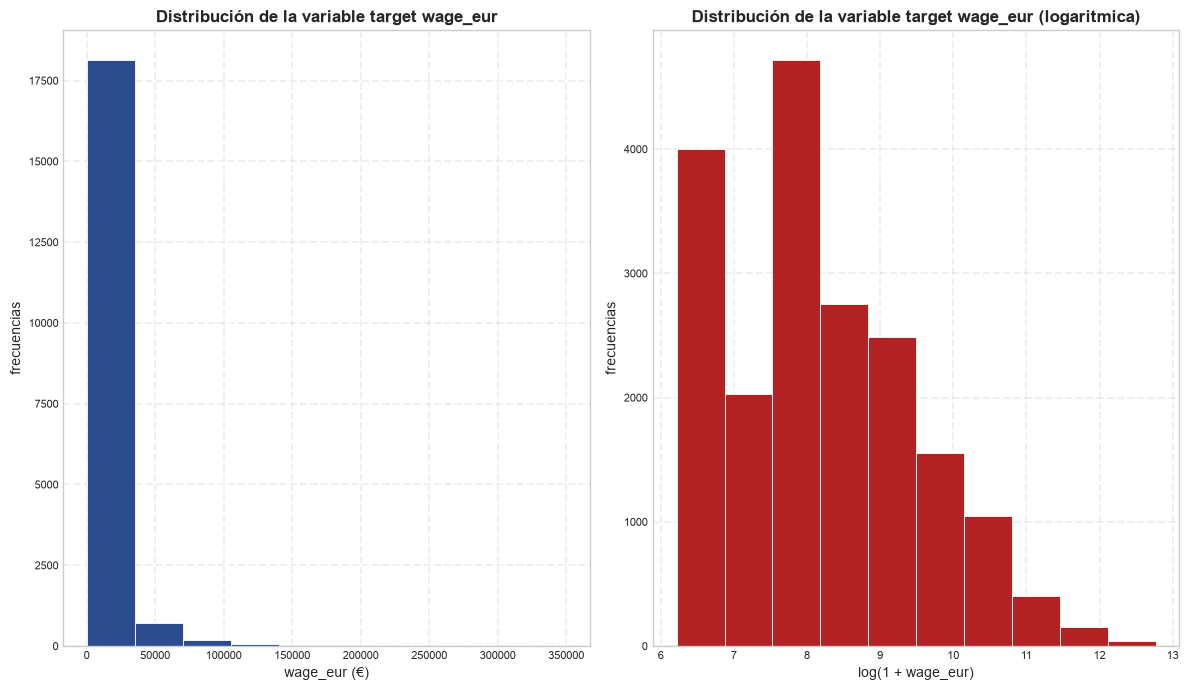

In [21]:
# Ya tenemos el dataframe, entonces, tendremos que trabajar con gráficos: matplotlib
#Gráficos
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 7))
color1 = "#2b4c8c"
color2 = "firebrick"

#Títulos y ejes
ax = axes[0]
ax.hist(df["wage_eur"], bins=10, color=color1, linewidth=0.6, edgecolor="white")
ax.set_title("Distribución de la variable target wage_eur", fontsize=12, fontweight="bold")
ax.set_xlabel("wage_eur (€)", fontsize=10)
ax.set_ylabel("frecuencias", fontsize=10)
ax.tick_params(labelsize=8)
ax.grid(alpha=0.3, linestyle="--", linewidth=1.4)

log_wage = np.log1p(df["wage_eur"])
ax = axes[1]
ax.hist(log_wage, bins=10, color=color2, linewidth=0.6, edgecolor="white")
ax.set_title("Distribución de la variable target wage_eur (logaritmica)", fontsize=12, fontweight="bold")
ax.set_xlabel("log(1 + wage_eur)", fontsize=10)
ax.set_ylabel("frecuencias", fontsize=10)
ax.tick_params(labelsize=8)
ax.grid(alpha=0.3, linestyle="--", linewidth=1.4)

#Visualización
plt.tight_layout()
plt.show()

In [22]:
# Cuantifiquemos la asimetría de la distribución antes y después de la transformación logarítmica
resumen_wage = pd.DataFrame({
    "wage_eur": [
        df["wage_eur"].mean(),
        df["wage_eur"].median(),
        df["wage_eur"].std(),
        df["wage_eur"].min(),
        df["wage_eur"].max(),
        df["wage_eur"].skew(),
        df["wage_eur"].kurtosis(),
    ],
    "log(1 + wage_eur)": [
        log_wage.mean(),
        log_wage.median(),
        log_wage.std(),
        log_wage.min(),
        log_wage.max(),
        log_wage.skew(),
        log_wage.kurtosis(),
    ],
}, index=["Media", "Mediana", "Desv. estándar", "Mínimo", "Máximo", "Asimetría (skew)", "Curtosis"])

resumen_wage.round(3)

,wage_eur,log(1 + wage_eur)
Media,9017.989,8.085
Mediana,3000.000,8.007
Desv. estándar,19470.177,1.360
Mínimo,500.000,6.217
Máximo,350000.000,12.766
Asimetría (skew),6.472,0.473
Curtosis,63.067,-0.465


<b>Explicación</b>: Los dos histogramas cuentan historias muy distintas. En su escala original, `wage_eur` se apiña casi por completo contra el extremo izquierdo: la enorme mayoría de futbolistas cobra sueldos modestos y solo un puñado se dispara hacia las cifras altas. Esto se refleja en los números: la media (≈ 9,018 €) prácticamente triplica a la mediana (3,000 €), señal clásica de que unos pocos salarios enormes empujan el promedio hacia arriba. La asimetría de **6.47** y la curtosis de **63** confirman una cola derecha larguísima y muy pesada, coherente con lo que ya intuíamos en el análisis de outliers: ese 12.5% de sueldos atípicos vive todo en esa cola.

Al aplicar la transformación logarítmica `log(1 + wage_eur)`, la distribución se ordena y toma una forma mucho más cercana a la campana: la asimetría cae de 6.47 a **0.47** y la curtosis se vuelve prácticamente normal. En términos futbolísticos, el logaritmo traduce la brecha salarial a una escala donde "duplicar el sueldo" pesa lo mismo ya sea que pasemos de 1,000 € a 2,000 € o de 100,000 € a 200,000 €, que es exactamente la manera en que se comportan los sueldos en el mercado real.

#### <b><i>Conclusión</i></b>
La variable objetivo `wage_eur` presenta una fuerte asimetría positiva: la mitad de los jugadores gana 3,000 € o menos, mientras que una minoría de estrellas alcanza cifras de hasta 350,000 €. Esta cola derecha, lejos de ser un defecto de los datos, es precisamente el fenómeno que buscamos explicar. La transformación logarítmica corrige esa asimetría casi por completo (skew de 6.47 → 0.47) y acerca la distribución a una forma normal, lo que la vuelve una candidata natural para el modelado posterior.

#### <b><i>Decisión</i></b>
Se conserva `wage_eur` en su escala original para el análisis exploratorio (facilita la lectura en euros), pero se deja registrado que la transformación `log(1 + wage_eur)` será la forma preferida de la variable objetivo al momento de modelar, dado que normaliza la distribución y estabiliza el peso de los sueldos extremos. La decisión definitiva sobre transformar el target se formaliza en la Fase 6 (Feature Engineering).

#### <b><i>3. Distribución de las variables más relevantes</i></b>
Ya conocemos cómo se comporta el sueldo. Ahora toca mirar a los protagonistas que podrían explicarlo. Analizaremos la distribución de cinco variables que, por criterio futbolístico, son candidatas naturales a influir en el salario: la **edad** (`age`), la **valoración general** (`overall`), el **potencial** (`potential`), la **estatura** (`height_cm`) y la **reacción en el juego** (`movement_reactions`). Entender su forma nos ayudará a saber con qué tipo de jugadores estamos trabajando antes de cruzarlos con el sueldo.

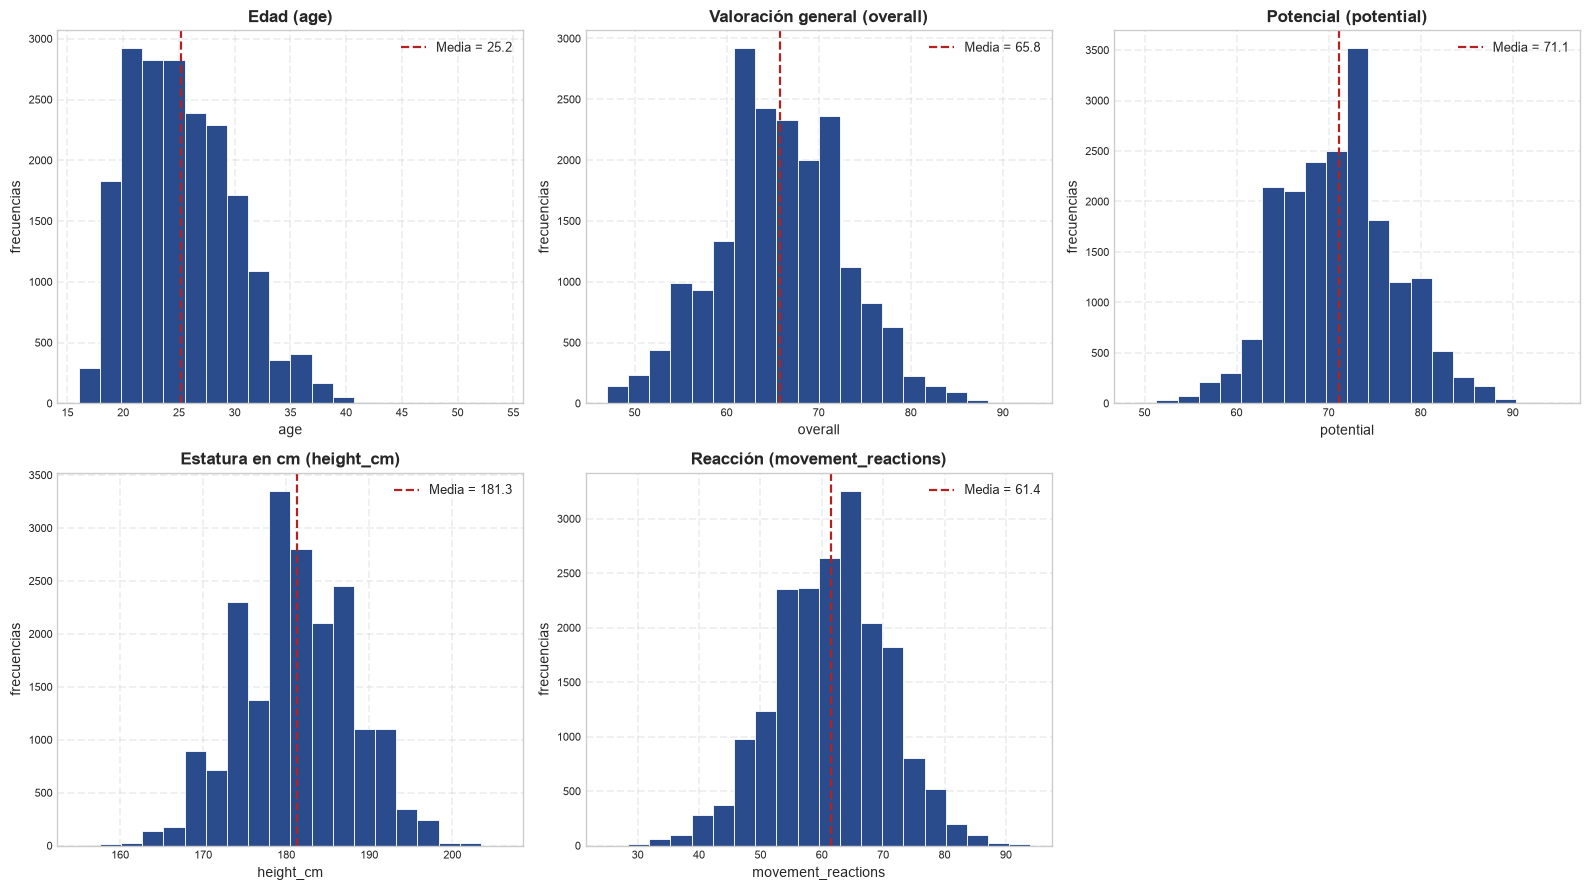

,age,overall,potential,height_cm,movement_reactions
count,19178.00,19178.00,19178.00,19178.00,19178.00
mean,25.20,65.76,71.08,181.29,61.44
std,4.75,6.88,6.09,6.86,9.04
min,16.00,47.00,49.00,155.00,25.00
25%,21.00,61.00,67.00,176.00,56.00
50%,25.00,66.00,71.00,181.00,62.00
75%,29.00,70.00,75.00,186.00,67.00
max,54.00,93.00,95.00,206.00,94.00


In [23]:
# Distribución de las 5 variables relevantes
variables_relevantes = ["age", "overall", "potential", "height_cm", "movement_reactions"]
titulos = {
    "age": "Edad (age)",
    "overall": "Valoración general (overall)",
    "potential": "Potencial (potential)",
    "height_cm": "Estatura en cm (height_cm)",
    "movement_reactions": "Reacción (movement_reactions)",
}

plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
color1 = "#2b4c8c"

for ax, col in zip(axes.flat, variables_relevantes):
    ax.hist(df_new[col], bins=20, color=color1, linewidth=0.6, edgecolor="white")
    ax.axvline(df_new[col].mean(), color="firebrick", linestyle="--", linewidth=1.6, label=f"Media = {df_new[col].mean():.1f}")
    ax.set_title(titulos[col], fontsize=12, fontweight="bold")
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel("frecuencias", fontsize=10)
    ax.tick_params(labelsize=8)
    ax.grid(alpha=0.3, linestyle="--", linewidth=1.4)
    ax.legend(fontsize=9)

# Ocultamos el sexto eje que queda vacío (solo tenemos 5 variables)
axes.flat[-1].set_visible(False)

plt.tight_layout()
plt.show()

# Tabla resumen de estadísticas descriptivas
df_new[variables_relevantes].describe().round(2)

<b>Explicación</b>: A diferencia del sueldo, estas cinco variables se comportan de forma mucho más ordenada, casi todas rondando una campana simétrica:

- **Edad (`age`)**: se concentra entre los 21 y 29 años, con media de ≈25. Hay una leve cola hacia la derecha (algunos veteranos de más de 35), pero en esencia es una plantilla mundial joven, en plena etapa productiva de su carrera.
- **Overall (`overall`)**: se distribuye casi perfectamente simétrica alrededor de 66. La gran masa de futbolistas es de nivel medio; los cracks de 85+ son escasísimos, coherente con que el talento de élite es raro por definición.
- **Potencial (`potential`)**: misma forma acampanada, pero desplazada hacia arriba (media ≈71). Que el potencial supere sistemáticamente al overall tiene todo el sentido: mide el techo al que el jugador *podría* llegar, no lo que ya es.
- **Estatura (`height_cm`)**: distribución prácticamente normal centrada en 181 cm, exactamente lo que uno esperaría de una población de deportistas profesionales.
- **Reacción (`movement_reactions`)**: campana centrada en ≈61, con dispersión algo mayor. Es un atributo que suele acompañar a la experiencia y la lectura de juego, por lo que anticipamos que conversará bien con el overall y el sueldo.

#### <b><i>Conclusión</i></b>
Las variables explicativas revisadas son mucho más "dóciles" que el sueldo: todas se aproximan a distribuciones simétricas, sin colas problemáticas ni valores absurdos. Esto contrasta de lleno con la fuerte asimetría de `wage_eur` y adelanta una idea clave del estudio: la enorme dispersión salarial **no** proviene de que las características de los jugadores estén desbalanceadas, sino de cómo el mercado premia de forma no lineal a los pocos que reúnen valoraciones altas. En otras palabras, una diferencia pequeña de overall en el extremo superior puede traducirse en una diferencia salarial gigantesca, algo que exploraremos al cruzar estas variables con el target.

#### <b><i>4. Correlación entre las variables numéricas y el sueldo</i></b>
Ya vimos por separado cómo se comportan el sueldo y sus posibles impulsores. El siguiente paso natural es preguntarnos: ¿cuáles de todos estos atributos se mueven de la mano con el salario? Para responderlo mediremos la correlación de cada variable numérica con `wage_eur`. Usaremos dos lentes complementarios: la correlación de **Pearson**, que capta relaciones lineales, y la de **Spearman**, que capta relaciones monótonas aunque no sean lineales. Comparar ambas será especialmente útil aquí, dado lo asimétrico que resultó el sueldo.

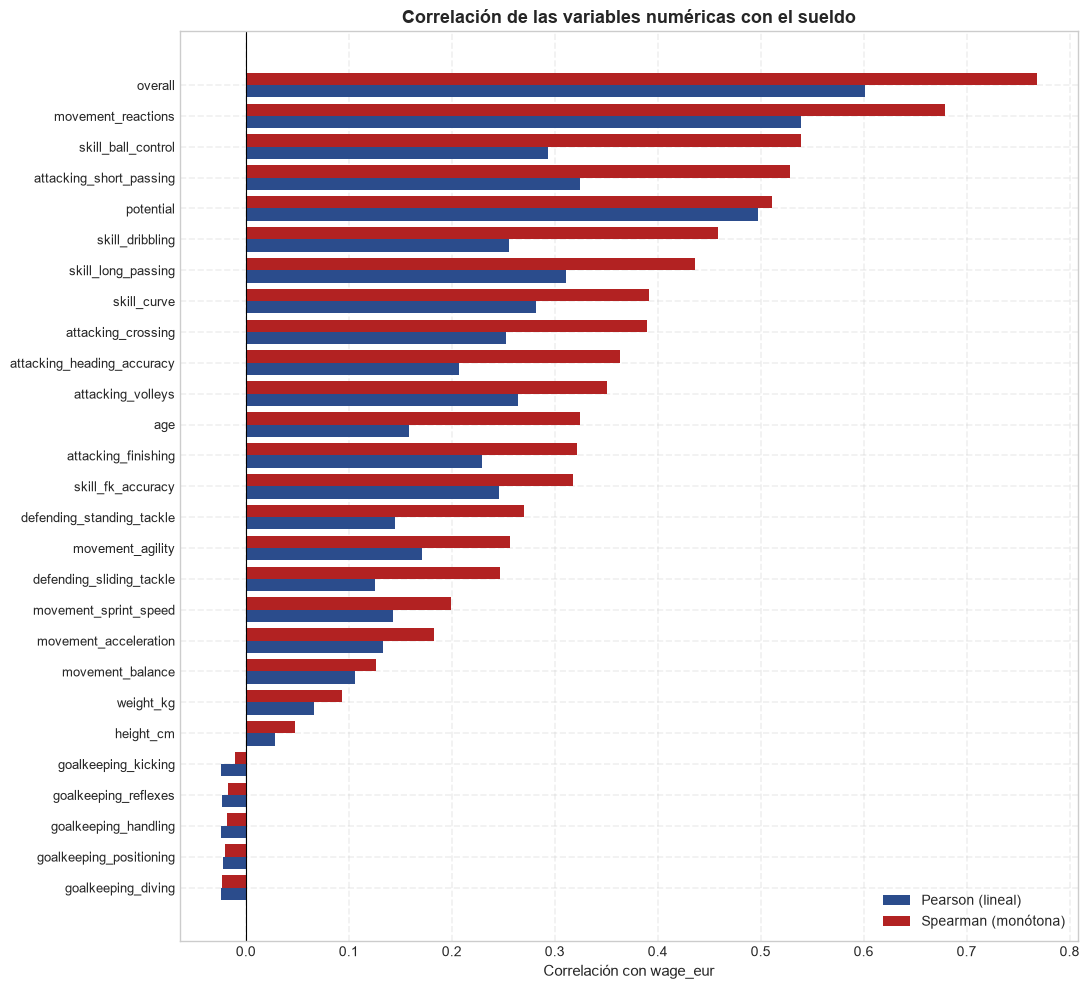

,Pearson,Spearman
overall,0.602,0.768
movement_reactions,0.540,0.679
skill_ball_control,0.293,0.540
attacking_short_passing,0.324,0.529
potential,0.498,0.511
skill_dribbling,0.255,0.459
skill_long_passing,0.311,0.436
skill_curve,0.281,0.392
attacking_crossing,0.253,0.389
attacking_heading_accuracy,0.207,0.363


In [24]:
# Correlación de cada variable numérica con el target, en sus dos versiones
num_cols = df_new.select_dtypes("number").columns

pearson = df_new[num_cols].corr(method="pearson")["wage_eur"].drop("wage_eur")
spearman = df_new[num_cols].corr(method="spearman")["wage_eur"].drop("wage_eur")

corr_target = pd.DataFrame({"Pearson": pearson, "Spearman": spearman})
corr_target = corr_target.sort_values("Spearman", ascending=False)

# Gráfico de barras horizontales comparando ambas correlaciones
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(11, 10))
orden = corr_target.sort_values("Spearman")
y = np.arange(len(orden))
ax.barh(y - 0.2, orden["Pearson"], height=0.4, color="#2b4c8c", label="Pearson (lineal)")
ax.barh(y + 0.2, orden["Spearman"], height=0.4, color="firebrick", label="Spearman (monótona)")
ax.set_yticks(y)
ax.set_yticklabels(orden.index, fontsize=9)
ax.set_xlabel("Correlación con wage_eur", fontsize=11)
ax.set_title("Correlación de las variables numéricas con el sueldo", fontsize=13, fontweight="bold")
ax.axvline(0, color="black", linewidth=0.8)
ax.grid(alpha=0.3, linestyle="--", linewidth=1.2)
ax.legend(fontsize=10, loc="lower right")
plt.tight_layout()
plt.show()

corr_target.round(3)

<b>Explicación</b>: El gráfico ordena todas las variables por su correlación con el sueldo y revela varias cosas de golpe:

- **Los tres grandes impulsores** son `overall` (Pearson 0.60 / Spearman 0.77), `movement_reactions` (0.54 / 0.68) y `potential` (0.50 / 0.51). Que el overall encabece la lista no sorprende: es, en esencia, la nota que resume la calidad del jugador, y el mercado paga por calidad. Lo interesante es que la reacción —la capacidad de leer y responder rápido al juego— aparezca tan arriba, por encima incluso del potencial.
- **Los atributos técnicos de campo** (pase corto, pase largo, control de balón, regate, centros) forman un pelotón intermedio, con correlaciones entre 0.25 y 0.32. Aportan, pero ninguno por sí solo manda.
- **Los atributos de portero** (`goalkeeping_*`) tienen correlación prácticamente nula, incluso levemente negativa. Esto es un artefacto esperable: como los porteros son minoría y sus habilidades específicas no aplican al grueso de jugadores de campo, esas columnas no explican el sueldo del conjunto.
- **El detalle más importante**: para casi todas las variables relevantes, **Spearman supera a Pearson**. En `overall`, por ejemplo, la brecha es enorme (0.77 vs 0.60). Esa diferencia es la huella de una relación **no lineal**: a medida que subimos de nivel, el sueldo no crece de forma proporcional, sino que se dispara. Es exactamente el fenómeno que anticipábamos con la asimetría del target.

#### <b><i>Conclusión</i></b>
El salario está gobernado sobre todo por indicadores de calidad global —`overall`, `movement_reactions` y `potential`— más que por habilidades técnicas puntuales, que juegan un papel secundario. Los atributos de portería no aportan señal sobre el conjunto y habrá que tratarlos con cuidado más adelante. Pero el hallazgo de fondo es metodológico: la superioridad sistemática de Spearman sobre Pearson confirma que la relación entre atributos y sueldo es **monótona pero no lineal**. Esto tiene una consecuencia directa para el modelado: los modelos puramente lineales quedarán en desventaja frente a los que capturan no linealidades (árboles, random forest, gradient boosting), y refuerza el atractivo de trabajar sobre `log(wage_eur)`.

#### <b><i>5. Relación entre la nacionalidad y el sueldo</i></b>
Hasta ahora todo lo que hemos mirado es medible en la cancha: edad, atributos, valoraciones. Pero el sueldo de un futbolista no vive en el vacío, sino dentro de un ecosistema: la liga en la que juega, el poder económico del fútbol de su país, la visibilidad de su mercado. La `nationality_name` es nuestra única variable categórica y sirve como una aproximación (imperfecta, pero útil) a ese contexto. Como decidimos en la parte de calidad de datos, nos centraremos en el **top 20 de países con más jugadores**, que concentra casi el 64% de la muestra y evita sacar conclusiones de países con apenas un par de futbolistas.

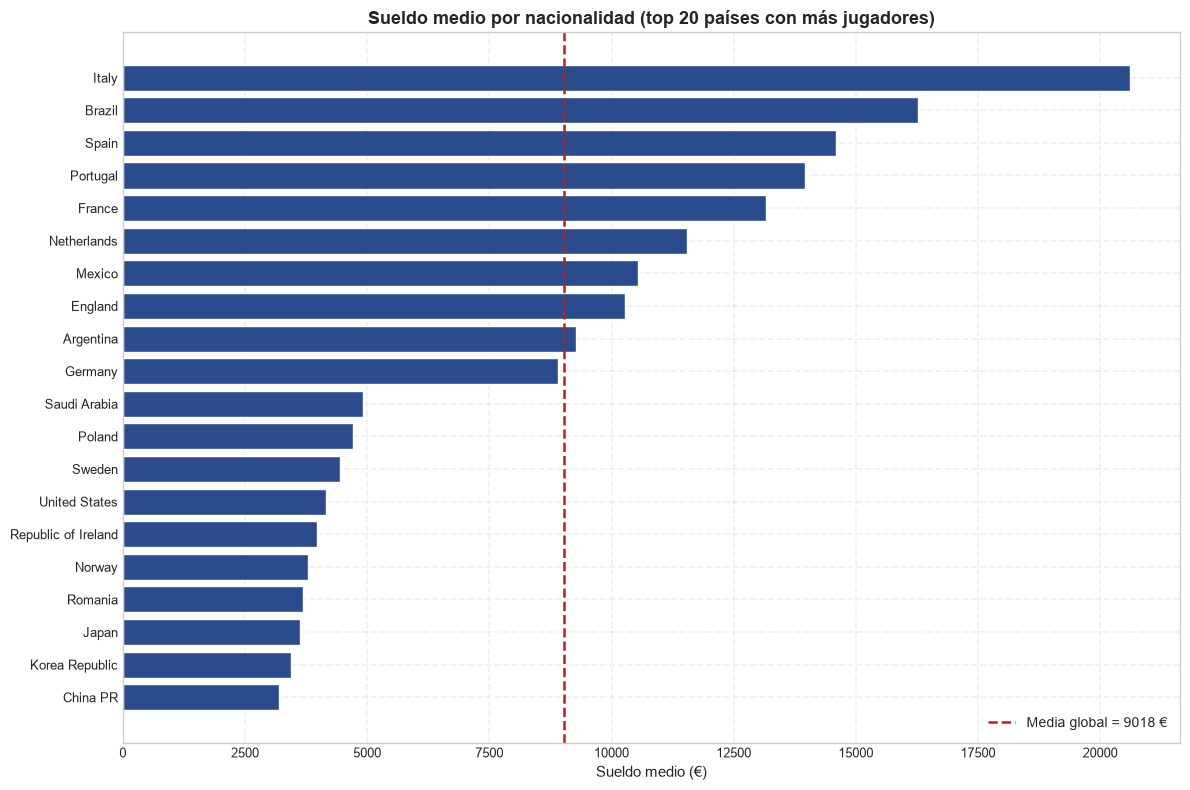

,count,mean,median
nationality_name,,,
Italy,338,20604.0,11000.0
Brazil,897,16266.0,9000.0
Spain,1086,14599.0,6000.0
Portugal,373,13967.0,5000.0
France,980,13164.0,4000.0
Netherlands,439,11535.0,3000.0
Mexico,352,10539.0,5000.0
England,1719,10270.0,3000.0
Argentina,960,9266.0,5000.0


In [25]:
# Trabajamos sobre el top 20 de países con más jugadores (definido en la sección de calidad de datos)
top20 = df_new["nationality_name"].value_counts().head(20).index
df_top20 = df_new[df_new["nationality_name"].isin(top20)]

# Sueldo medio y mediano por país, ordenado por la media
wage_por_pais = (
    df_top20.groupby("nationality_name")["wage_eur"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

# Gráfico de barras del sueldo medio por país
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(12, 8))
orden = wage_por_pais.sort_values("mean")
ax.barh(orden.index, orden["mean"], color="#2b4c8c", edgecolor="white")
ax.axvline(df_new["wage_eur"].mean(), color="firebrick", linestyle="--", linewidth=1.8,
           label=f"Media global = {df_new['wage_eur'].mean():.0f} €")
ax.set_xlabel("Sueldo medio (€)", fontsize=11)
ax.set_title("Sueldo medio por nacionalidad (top 20 países con más jugadores)", fontsize=13, fontweight="bold")
ax.tick_params(labelsize=9)
ax.grid(alpha=0.3, linestyle="--", linewidth=1.2)
ax.legend(fontsize=10, loc="lower right")
plt.tight_layout()
plt.show()

wage_por_pais.round(0)

<b>Explicación</b>: El contraste entre países es enorme y cuenta una historia muy futbolística:

- En lo más alto aparecen las potencias tradicionales del fútbol europeo y sudamericano: **Italia, Brasil, España, Bélgica, Portugal y Francia** encabezan el sueldo medio, todas por encima —o muy cerca— de la media global. Son las canteras que nutren a las grandes ligas (Serie A, LaLiga, Premier, Ligue 1) donde circula el dinero grande.
- En el otro extremo, países como **India, Australia o Sudáfrica** tienen sueldos medios muy por debajo del promedio, reflejo de ligas locales con mucha menor capacidad económica y jugadores que rara vez dan el salto a los circuitos de élite.
- Un matiz clave: en casi todos los países la **media supera con creces a la mediana** (Brasil: media ≈16,000 € vs mediana 9,000 €; España: 14,600 € vs 6,000 €). Es la misma cola derecha de siempre asomando dentro de cada país: unas pocas superestrellas nacionales elevan el promedio, mientras el jugador típico de esa nacionalidad cobra bastante menos.

#### <b><i>Conclusión</i></b>
La nacionalidad sí guarda relación con el sueldo, pero es una relación **de contexto, no de causa**: un jugador no gana más por ser brasileño, sino porque los mejores brasileños tienden a jugar en las ligas más ricas. La variable resume, de forma comprimida, el poder económico del entorno futbolístico de cada país. Esto la vuelve informativa para el modelo, aunque con dos cautelas que arrastraremos a la Fase 6: su **alta cardinalidad** (más de 150 países) obliga a codificarla con cuidado —agrupando o usando target/frequency encoding en lugar de un one-hot ingenuo—, y hay que vigilar que no introduzca sesgos indeseados. Por ahora queda claro que aporta señal de contexto que las variables puramente deportivas no capturan.

#### <b><i>6. Hallazgos en lenguaje de negocio</i></b>
Cerramos el EDA traduciendo lo que los gráficos y los números nos han contado a un lenguaje que cualquier persona del club —un director deportivo, un área de scouting, la gerencia— pueda leer sin mirar una sola línea de código. Estos son los hallazgos que sostendrán el resto del estudio.

**Hallazgo 1 — El sueldo es un juego de élites, no de promedios.**
La mitad de los futbolistas del mundo gana 3,000 € o menos, pero un puñado de estrellas llega hasta 350,000 €. Esa brecha brutal (la media casi triplica a la mediana) significa que el mercado no reparte el dinero de forma gradual: lo concentra de golpe en muy pocos. Para el negocio, esto implica que **cualquier análisis o modelo de sueldos debe estar diseñado para explicar los extremos**, no el jugador promedio, porque es en esos extremos donde se mueve el presupuesto de verdad.

**Hallazgo 2 — La calidad global manda; el talento suelto, no tanto.**
Tres variables se destacan claramente como impulsoras del sueldo: la valoración general (`overall`), la capacidad de reacción en el juego (`movement_reactions`) y el potencial (`potential`). En cambio, habilidades técnicas puntuales como el regate o los centros pesan mucho menos por sí solas. El mensaje para scouting y planificación es directo: **el mercado paga por jugadores completos y de alto nivel general, no por especialistas en una sola destreza**. Un crack de un solo truco vale menos que un futbolista sólido en todo.

**Hallazgo 3 — La relación entre nivel y sueldo es explosiva, no proporcional.**
Los datos muestran que subir de nivel no aumenta el sueldo de forma lineal: pasar de bueno a excelente puede multiplicar el salario, no solo sumarle un poco. Lo confirmamos al ver que las correlaciones monótonas (Spearman) superan siempre a las lineales (Pearson). En términos de negocio, esto explica por qué **los últimos puntos de `overall` de un fichaje estrella cuestan tan desproporcionadamente caros**, y anticipa que necesitaremos modelos capaces de capturar esa curva explosiva, no una simple recta.

**Hallazgo 4 (complementario) — La nacionalidad pesa como contexto de mercado.**
Los jugadores de las grandes potencias futbolísticas (Italia, Brasil, España, Francia) cobran en promedio más que los de ligas emergentes. No es que la nacionalidad haga mejor a nadie, sino que refleja en qué ecosistema económico se desarrolla su carrera. Es una señal de contexto valiosa que las estadísticas deportivas por sí solas no capturan, y que habrá que incorporar con cuidado al modelo.

### <b>CIERRE DEL ANÁLISIS EXPLORATORIO</b>
El EDA nos deja un retrato claro del problema: un sueldo fuertemente asimétrico, gobernado por indicadores de calidad global mediante una relación no lineal, y matizado por el contexto de mercado que aporta la nacionalidad. Estos hallazgos no son solo descriptivos: marcan el rumbo de las siguientes fases —sugieren transformar el target con logaritmo, priorizar `overall`, `movement_reactions` y `potential`, tratar con cuidado los atributos de portero y la nacionalidad, y preferir modelos capaces de capturar no linealidades. Con este mapa en mano, pasamos a validar estadísticamente algunas de estas intuiciones en la fase de estadística inferencial.